# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

In [ ]:
!pip install pytorch_lightning
!pip install torch-audiomentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.2 MB/s eta 0:00:00
  Created wheel for julius: filename=julius-0.2.7-py3-none-any.whl size=21870 sha256=2556c82fb050a5752b2d696f662d5f98634091e9dbfb18e43c8b9661554e6348
  Stored in directory: /root/.cache/pip/wheels/de/c1/ca/544dafe48401e8e2e17064dfe465a390fca9e8720ffa12e744
Successfully built julius


## AudioSet

Dataset with 10 numbers pronounced


In [ ]:
!git clone https://github.com/soerenab/AudioMNIST.git

fatal: destination path 'AudioMNIST' already exists and is not an empty directory.


### Dataset

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import pandas as pd
from pathlib import Path
from typing import Optional

import copy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import os

import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F

import pytorch_lightning as pl

from dataclasses import dataclass

from torch.utils.data import DataLoader, Subset

from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

## PyTorch Lightning фиксирует генераторы случайных чисел
pl.seed_everything(42, workers=True)


Seed set to 42


42

In [ ]:
@dataclass
class Config:
    data_path: str = "/kaggle/working/AudioMNIST/data"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size: int = 128
    num_workers: int = 4
    num_test_speakers: int = 12
    sample_rate: int = 16000
    max_duration_sec: float = 1.0

config = Config()

In [ ]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, is_test=False, augmentations=None, sr=16000, max_duration_sec=1.0):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)
        self.augmentations = augmentations
        self.is_test = is_test
        self.target_length = int(sr * max_duration_sec)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]

        # fixed-length audio: crop or right-pad
        current_length = wav.size(1)

        if current_length > self.target_length:
            wav = wav[:, :self.target_length]
        elif current_length < self.target_length:
            pad_amount = self.target_length - current_length
            wav = F.pad(wav, (0, pad_amount))

        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        if self.augmentations and not self.is_test:
            wav = self._augmentation(wav)

        return wav, label

    def _augmentation(self, signal):
        signal = self.augmentations(
            samples=signal.unsqueeze(0),
            sample_rate=self.sr,
        ).squeeze(0)

        signal = torch.clamp(signal, -1.0, 1.0)
        return signal

def collate(batch):
    wavs, labels = zip(*batch)

    # now every waveform already has the same length
    wavs = torch.stack([w.squeeze(0) for w in wavs], dim=0)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)

    return wavs, labels


# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(config.data_path)
_test_dataset[0]

(tensor([[0.0003, 0.0005, 0.0004,  ..., 0.0000, 0.0000, 0.0000]]), 0)

In [ ]:
from torch_audiomentations import Compose, Gain, AddColoredNoise, Shift, PolarityInversion

train_augmentations = Compose(
    transforms=[
        Gain(
            min_gain_in_db=-8.0,
            max_gain_in_db=8.0,
            p=0.4,
        ),
        AddColoredNoise(
            min_snr_in_db=8.0,
            max_snr_in_db=25.0,
            p=0.4,
        ),
        Shift(
            min_shift=-0.15,
            max_shift=0.15,
            p=0.4,
        ),
        PolarityInversion(p=0.2),
    ]
)

In [ ]:
class AudioDataModule(pl.LightningDataModule):
    def __init__(
        self,
        config: Config,
    ):
        super().__init__()
        self.root = config.data_path
        self.batch_size = config.batch_size
        self.num_workers = config.num_workers
        self.num_test_speakers = config.num_test_speakers
        self.sample_rate = config.sample_rate
        self.max_duration_sec = config.max_duration_sec

    def setup(self, stage=None):

        self.full_ds = AudioMNISTDataset(root=self.root)

        all_speakers = sorted({spk for (_, _, spk) in self.full_ds.items})
        valid_speakers = set(all_speakers[-self.num_test_speakers:])

        train_idxs, valid_idxs = self.split_indices_by_speaker(self.full_ds, valid_speakers)

        train_full = AudioMNISTDataset(
            root=self.root,
            is_test=False,
            augmentations=train_augmentations,
            sr=self.sample_rate,
            max_duration_sec=self.max_duration_sec,
        )

        valid_full = AudioMNISTDataset(
            root=self.root,
            is_test=True,
            augmentations=None,
            sr=self.sample_rate,
            max_duration_sec=self.max_duration_sec,
        )

        self.train_ds = Subset(train_full, train_idxs)
        self.valid_ds = Subset(valid_full, valid_idxs)

        print("Train samples:", len(train_idxs))
        print("Valid samples:", len(valid_idxs))
        print("Valid speakers:", sorted(valid_speakers))

        train_speakers = {spk for i in train_idxs for (_, _, spk) in [self.full_ds.items[i]]}
        valid_speakers = {spk for i in valid_idxs for (_, _, spk) in [self.full_ds.items[i]]}

        print("Speakers leakage:", bool(train_speakers & valid_speakers))

    def split_indices_by_speaker(self, dataset, test_speakers):
        train_idxs = []
        test_idxs = []

        for idx, (_, _, spk) in enumerate(dataset.items):
            if spk in test_speakers:
                test_idxs.append(idx)
            else:
                train_idxs.append(idx)

        return train_idxs, test_idxs

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
            pin_memory=True,
            collate_fn=collate,
        )

    def val_dataloader(self):
        return DataLoader(
            self.valid_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
            pin_memory=True,
            collate_fn=collate,
        )

## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

### Model

#### ResNet1D

In [ ]:
class BlockResNet1D(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x = x + identity
        x = self.relu(x)
        return x


class ResNet1D(nn.Module):
    # ResNet-18 style: [2, 2, 2, 2]
    def __init__(self, block, input_channels=1):
        super().__init__()

        layers = [2, 2, 2, 2]
        self.expansion = 1
        self.in_channels = 64

        self.conv1 = nn.Conv1d(
            input_channels,
            self.in_channels,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, layers[0], out_channels=64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], out_channels=128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], out_channels=256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], out_channels=512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(1)

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * self.expansion:
            identity_downsample = nn.Sequential(
                nn.Conv1d(
                    self.in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm1d(out_channels * self.expansion),
            )

        layers.append(
            block(
                self.in_channels,
                out_channels,
                identity_downsample=identity_downsample,
                stride=stride,
            )
        )
        self.in_channels = out_channels * self.expansion

        for _ in range(1, num_residual_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # x: [B, C, T]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)   # [B, 512, 1]
        return x


def CreateResNet1D(input_channels=1):
    return ResNet1D(BlockResNet1D, input_channels=input_channels)

#### ResNet2D


In [ ]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        mel = super().forward(waveform)
        mel = torch.clamp(mel, min=self.eps)
        return mel.log()

In [ ]:
class ResNet2D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet2D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x

    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)

In [ ]:
class BlockResNet2D(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(BlockResNet2D, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

def CreateResNet2D(img_channels=3):
    return ResNet2D(BlockResNet2D, image_channels=img_channels)

In [ ]:
class SpectrogramEncoder(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 10):
        super(SpectrogramEncoder, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - specs_emb used for contrastive loss
                - spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.flatten(1)

        specs_emb = self.output(spectograms)

        return specs_emb, spectograms


class ClassificationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 10):
        super(ClassificationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

#### Classifier

In [ ]:
class AudioClassifierLitModule(pl.LightningModule):
    def __init__(
        self,
        num_classes: int = 10,
        sample_rate: int = 16000,
        n_fft: int = 1024,
        hop_length: int = 256,
        win_length: int = 1024,
        n_mels: int = 64,
        lr: float = 1e-3,
        weight_decay: float = 1e-4,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.melspec = LogMelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
            eps=1e-6,
        )

        self.encoder = SpectrogramEncoder(img_channels=1)
        self.head = ClassificationHead(num_classes=num_classes)

    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        """
        waveform: [B, T] or [B, 1, T]
        returns logits: [B, num_classes]
        """
        x = self.melspec(waveform)   # [B, n_mels, time]
        x = x.unsqueeze(1)           # [B, 1, n_mels, time]

        _, spectrogram_features = self.encoder(x)   # [B, 512]
        logits = self.head(spectrogram_features)    # [B, num_classes]
        return logits

    def _shared_step(self, batch, stage: str):
        """
        Ожидается batch = (waveform, label)
        waveform: [B, T] or [B, 1, T]
        label: [B]
        """
        waveform, label = batch
        logits = self(waveform)
        loss = F.cross_entropy(logits, label)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == label).float().mean()

        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_acc", acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=waveform.size(0))

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=3,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_acc",
                "interval": "epoch",
                "frequency": 1,
            },
        }

### Training and Evaluation

In [ ]:
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

dm = AudioDataModule(config)

model_supervised = AudioClassifierLitModule()

checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=3,
    filename="supervised-audio-{epoch:02d}-{val_acc:.2f}",
)

early_stop_callback = EarlyStopping(
    monitor="val_acc",
    min_delta=0.001,
    patience=5,
    mode="max",
)

logger = CSVLogger("logs", name="supervised_audio")

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
precision = "16-mixed" if torch.cuda.is_available() else 32

trainer = pl.Trainer(
    max_epochs=100,
    accelerator=accelerator,
    devices=1,
    precision=precision,
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

trainer.fit(model_supervised, dm)

print("Best checkpoint:", checkpoint_callback.best_model_path)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Train samples: 24000
Valid samples: 6000
Valid speakers: ['49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60']
Speakers leakage: False


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ melspec │ LogMelSpectrogram  │      0 │ train │     0 │
│ 1 │ encoder │ SpectrogramEncoder │  7.2 M │ train │     0 │
│ 2 │ head    │ ClassificationHead │  5.1 K │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 7.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 M                                                                                                
Total estimated model params size (MB): 28                                                                         
Modules in train mode: 82                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Best checkpoint: logs/supervised_audio/version_8/checkpoints/supervised-audio-epoch=15-val_acc=1.00.ckpt


### Metrics and Visualisation

In [ ]:
def plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


Best val_acc:  0.9975 at epoch 15
Best val_loss: 0.0065 at epoch 15
Best model path: logs/supervised_audio/version_8/checkpoints/supervised-audio-epoch=15-val_acc=1.00.ckpt
Best model score: 0.9975


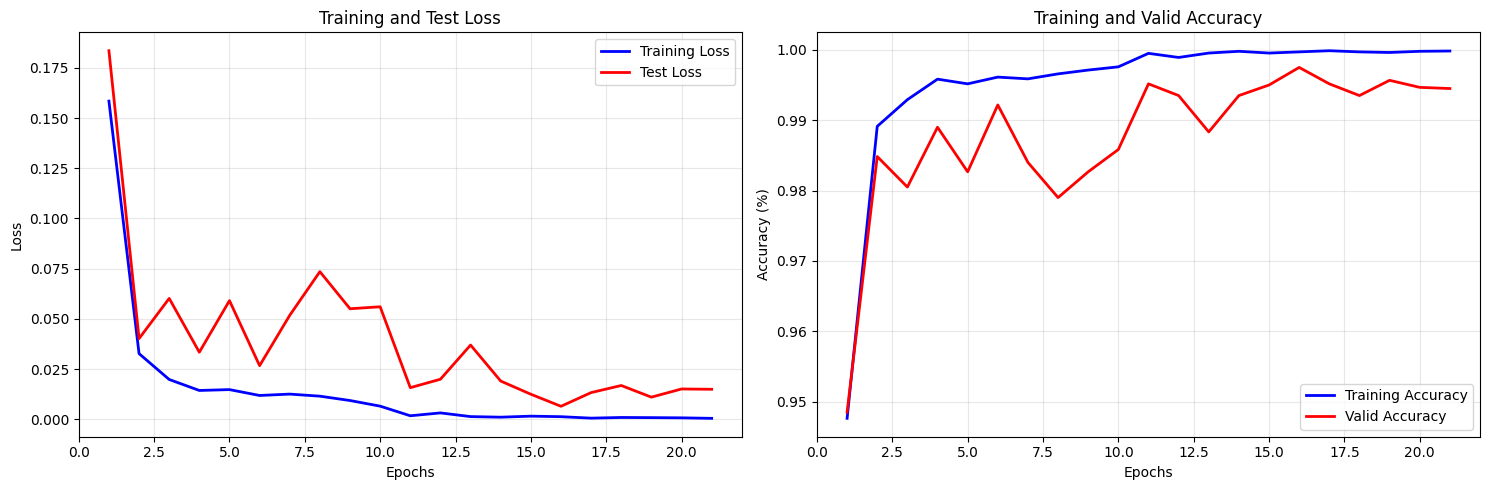

In [ ]:
metrics_path = os.path.join(logger.log_dir, "metrics.csv")

# Load the metrics
metrics_df = pd.read_csv(metrics_path)
train_metrics = metrics_df.dropna(subset=['train_loss']).set_index('epoch')
val_metrics = metrics_df.dropna(subset=['val_loss']).set_index('epoch')

print(f"Best val_acc:  {val_metrics['val_acc'].max():.4f} at epoch {val_metrics['val_acc'].idxmax()}")
print(f"Best val_loss: {val_metrics['val_loss'].min():.4f} at epoch {val_metrics['val_loss'].idxmin()}")

print(f"Best model path: {checkpoint_callback.best_model_path}")
print(f"Best model score: {checkpoint_callback.best_model_score:.4f}")

# Get common epochs to ensure alignment
common_epochs = sorted(list(set(train_metrics.index) & set(val_metrics.index)))

# Extract metrics for common epochs
train_losses = train_metrics.loc[common_epochs, 'train_loss'].tolist()
train_accuracies = train_metrics.loc[common_epochs, 'train_acc'].tolist()
test_losses = val_metrics.loc[common_epochs, 'val_loss'].tolist()
test_accuracies = val_metrics.loc[common_epochs, 'val_acc'].tolist()

# Plot the metrics
plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies)


1. есть конфликт с crop в Audiodataset
```
wav = wav[:, :self.target_length]
```
потом аугементация Shift(...)

Проблема:

Shift может "сдвинуть" сигнал → часть станет тишиной

Но Вы уже обрезали → теряется часть информации

В итоге модель иногда видит "обрезанные цифры".

Решение:
* Либо делать random crop ДО аугментаций
* Либо делать augment, потом crop/pad
```
wav = self.load_wav(path)

if self.augmentations and not self.is_test:
    wav = self._augmentation(wav)

wav = self.fix_length(wav)
```

2. Слишком высокая суммарная вероятность: 0.4 + 0.4 + 0.4 + 0.2.

Это значит, часто применяется 2–3 аугментации сразу

Иногда это хорошо, но для AudioMNIST может быть перебор.

Более стабильный вариант:
```
Compose([
    OneOf([
        Gain(...),
        AddColoredNoise(...),
        Shift(...),
    ], p=0.7),
    PolarityInversion(p=0.2),
])
```
Это уменьшает "разрушение" сигнала и даёт более стабильное обучение.

3.  Shift может добавлять тишину

В torch_audiomentations Shift обычно делает roll или pad

иногда добавляется нулевая область. Это может портить короткие записи и создавать артефакты.

4. Нет time masking / freq masking👉 Для AudioMNIST часто лучше работают спектрограммы + SpecAugment, чем raw waveform.

Рекомендации (если хотите улучшить качество) 
- Минимум: random crop + чуть уменьшить агрессивность аугментаций.
- Средний уровень: добавить TimeMask(...)
- Продвинутый вариант: перейти на MelSpectrogram + SpecAugment.

---

Замечания по модели
1. НЕТ нормализации mel-спектрограммы (самое важное)
сейчас : mel = mel.log()
но значения могут быть сильно разные по масштабу, зависеть от громкости.
Это одна из главных причин плохого обучения
Добавьте нормализацию:
```
mel = mel.log()
mel = (mel - mel.mean(dim=-1, keepdim=True)) / (mel.std(dim=-1, keepdim=True) + 1e-6)
```
или глобально:
```
mel = (mel - mel.mean()) / (mel.std() + 1e-6)
```
2. Вход в MelSpectrogram может быть неправильной формы. 

У Вас waveform: [B, T] or [B, 1, T], но torchaudio ожидает [B, T] или [C, T].

Потенциальный баг: если вдруг придёт [B, 1, T], то mel может сломаться или вести себя странно.

Fix:
```
if waveform.dim() == 3:
    waveform = waveform.squeeze(1)
```

3. Слишком агрессивный downsampling. Посчитаем:
* conv1 stride=2
* maxpool stride=2
* layer2 stride=2
* layer3 stride=2
* layer4 stride=2

итого: /32 по времени и частоте

Для коротких аудио это может убить сигнал.
Fix (лучший вариант): убрать maxpool или уменьшить stride в ранних слоях, например:
```
self.maxpool = nn.Identity()
```
4. Нет dropout вообще - сейчас модель легко может переобучаться. Добавьте в SpectrogramEncoder:
```
nn.Linear(512, 256),
nn.BatchNorm1d(256),
nn.ReLU(),
nn.Dropout(0.3),
```
5. ClassificationHead слишком простой.
иногда ок, но можно лучше
```
nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
```
6. Нет weight initialization. Не критично, но ResNet обычно выигрывает от хорошей инициализациию

7. Scheduler может срабатывать странно тут: ReduceLROnPlateau(mode="max", monitor="val_acc")

проблема:
* accuracy скачет
* scheduler может дергаться

Иногда лучше:
* monitor "val_loss"
* или использовать CosineAnnealingLR

8. Вы не используете embedding (128)
```
specs_emb = self.output(...)
```
если не нужен → уберите

---

сильные стороны: общая архитектура, lighting module, Encoder

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

### Model

In [ ]:
class SpecEncoder2D(nn.Module):
    def __init__(self, img_channels=1, emb_dim=128, dropout_p=0.1):
        super().__init__()
        self.backbone = CreateResNet2D(img_channels=img_channels)
        self.proj = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(256, emb_dim),
        )

    def forward(self, x):
        feats = self.backbone(x)      # [B, 512, 1, 1]
        feats = feats.flatten(1)      # [B, 512]
        emb = self.proj(feats)        # [B, emb_dim]
        return emb, feats

In [ ]:
class WaveEncoder1D(nn.Module):
    """
    input:  [B, 1, T]
    output: [B, emb_dim]
    """
    def __init__(self, emb_dim: int = 128, dropout_p: float = 0.2):
        super().__init__()

        self.backbone = CreateResNet1D(input_channels=1)
        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(256, emb_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)   # [B, 512, 1]
        x = x.flatten(1)       # [B, 512]
        x = self.output(x)     # [B, emb_dim]
        return x

In [ ]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim: int, proj_dim: int, hidden_dim: int = 256, dropout_p: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(hidden_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class MFCLLitModule(pl.LightningModule):
    def __init__(
        self,
        sample_rate: int = 16000,
        n_fft: int = 1024,
        hop_length: int = 256,
        win_length: int = 1024,
        n_mels: int = 64,
        emb_dim: int = 128,
        proj_dim: int = 128,
        temperature: float = 0.1,
        lr: float = 3e-4,
        weight_decay: float = 1e-3,
        dropout_p: float = 0.2,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.melspec = LogMelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
            eps=1e-6,
        )

        self.wav_encoder = WaveEncoder1D(emb_dim=emb_dim, dropout_p=dropout_p)
        self.spec_encoder = SpecEncoder2D(img_channels=1, emb_dim=emb_dim, dropout_p=dropout_p)

        self.wav_proj = ProjectionHead(in_dim=emb_dim, proj_dim=proj_dim, dropout_p=dropout_p)
        self.spec_proj = ProjectionHead(in_dim=emb_dim, proj_dim=proj_dim, dropout_p=dropout_p)

    def encode_wave(self, waveform: torch.Tensor) -> torch.Tensor:
        if waveform.dim() == 2:
            waveform = waveform.unsqueeze(1)   # [B, 1, T]

        wav_emb = self.wav_encoder(waveform)
        z_wav = self.wav_proj(wav_emb)
        z_wav = F.normalize(z_wav, dim=1)
        return z_wav

    def encode_spec(self, waveform: torch.Tensor) -> torch.Tensor:
        if waveform.dim() == 3:
            waveform = waveform.squeeze(1)     # [B, T]

        mel = self.melspec(waveform)           # [B, n_mels, time]
        mel = mel.unsqueeze(1)                 # [B, 1, n_mels, time]

        spec_emb, _ = self.spec_encoder(mel)
        z_spec = self.spec_proj(spec_emb)
        z_spec = F.normalize(z_spec, dim=1)
        return z_spec

    def forward(self, waveform: torch.Tensor):
        z_wav = self.encode_wave(waveform)
        z_spec = self.encode_spec(waveform)
        return z_wav, z_spec

    def _shared_step(self, batch, stage: str):
        waveform, _ = batch

        z_wav, z_spec = self(waveform)

        logits = (z_wav @ z_spec.T) / self.hparams.temperature
        targets = torch.arange(logits.size(0), device=logits.device)

        loss_ws = F.cross_entropy(logits, targets)
        loss_sw = F.cross_entropy(logits.T, targets)
        loss = 0.5 * (loss_ws + loss_sw)

        preds_ws = logits.argmax(dim=1)
        preds_sw = logits.T.argmax(dim=1)

        acc_ws = (preds_ws == targets).float().mean()
        acc_sw = (preds_sw == targets).float().mean()
        acc = 0.5 * (acc_ws + acc_sw)

        sim = z_wav @ z_spec.T
        pos_sim = sim.diag().mean()

        mask = ~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)
        neg_sim = sim[mask].mean()

        sim_gap = pos_sim - neg_sim

        z_wav_std = z_wav.std(dim=0).mean()
        z_spec_std = z_spec.std(dim=0).mean()

        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_acc", acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_pos_sim", pos_sim, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_neg_sim", neg_sim, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_sim_gap", sim_gap, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_z_wav_std", z_wav_std, on_step=False, on_epoch=True, batch_size=waveform.size(0))
        self.log(f"{stage}_z_spec_std", z_spec_std, on_step=False, on_epoch=True, batch_size=waveform.size(0))

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=100,
            eta_min=1e-5,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            },
        }

### Training and Evaluation

In [ ]:
dm = AudioDataModule(config)

model_mfcl = MFCLLitModule(
    sample_rate=16000,
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_mels=64,
    emb_dim=128,
    proj_dim=128,
    temperature=0.1,
    lr=3e-4,
    weight_decay=1e-3,
    dropout_p=0.2,
)

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="mfcl-audio-{epoch:02d}-{val_loss:.4f}",
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    mode="min",
)

logger = CSVLogger("logs", name="mfcl_audio")

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
precision = "16-mixed" if torch.cuda.is_available() else 32

trainer = pl.Trainer(
    max_epochs=100,
    accelerator=accelerator,
    devices=1,
    precision=precision,
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

trainer.fit(model_mfcl, dm)

print("Best checkpoint:", checkpoint_callback.best_model_path)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Train samples: 24000
Valid samples: 6000
Valid speakers: ['49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60']
Speakers leakage: False


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ melspec      │ LogMelSpectrogram │      0 │ train │     0 │
│ 1 │ wav_encoder  │ WaveEncoder1D     │  3.0 M │ train │     0 │
│ 2 │ spec_encoder │ SpecEncoder2D     │  7.1 M │ train │     0 │
│ 3 │ wav_proj     │ ProjectionHead    │  132 K │ train │     0 │
│ 4 │ spec_proj    │ ProjectionHead    │  132 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 10.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.4 M                                                                                               
Total estimated model params size (MB): 41                                                                         
Modules in train mode: 177                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Best checkpoint: logs/mfcl_audio/version_3/checkpoints/mfcl-audio-epoch=10-val_loss=2.6861.ckpt


### Metrics and Visualisation

In [ ]:
def plot_mfcl_metrics(metrics_path: str):
    metrics_df = pd.read_csv(metrics_path)

    train_metrics = metrics_df.dropna(subset=["train_loss"]).copy()
    val_metrics = metrics_df.dropna(subset=["val_loss"]).copy()

    train_metrics = train_metrics.groupby("epoch", as_index=False).last()
    val_metrics = val_metrics.groupby("epoch", as_index=False).last()

    common_epochs = sorted(set(train_metrics["epoch"]) & set(val_metrics["epoch"]))
    train_metrics = train_metrics[train_metrics["epoch"].isin(common_epochs)].sort_values("epoch")
    val_metrics = val_metrics[val_metrics["epoch"].isin(common_epochs)].sort_values("epoch")

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    # 1. Loss
    axes[0, 0].plot(train_metrics["epoch"], train_metrics["train_loss"], label="Train Loss", linewidth=2)
    axes[0, 0].plot(val_metrics["epoch"], val_metrics["val_loss"], label="Val Loss", linewidth=2)
    axes[0, 0].set_title("MFCL InfoNCE Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # 2. Retrieval accuracy
    axes[0, 1].plot(train_metrics["epoch"], train_metrics["train_acc"], label="Train Retrieval Acc", linewidth=2)
    axes[0, 1].plot(val_metrics["epoch"], val_metrics["val_acc"], label="Val Retrieval Acc", linewidth=2)
    axes[0, 1].set_title("MFCL Retrieval Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # 3. Positive / negative similarity
    if {"train_pos_sim", "train_neg_sim", "train_sim_gap"}.issubset(train_metrics.columns):
        axes[1, 0].plot(train_metrics["epoch"], train_metrics["train_pos_sim"], label="Train Pos Sim", linewidth=2)
        axes[1, 0].plot(train_metrics["epoch"], train_metrics["train_neg_sim"], label="Train Neg Sim", linewidth=2)
        axes[1, 0].plot(train_metrics["epoch"], train_metrics["train_sim_gap"], label="Train Sim Gap", linewidth=2)
        if {"val_pos_sim", "val_neg_sim", "val_sim_gap"}.issubset(val_metrics.columns):
            axes[1, 0].plot(val_metrics["epoch"], val_metrics["val_pos_sim"], label="Val Pos Sim", linestyle="--")
            axes[1, 0].plot(val_metrics["epoch"], val_metrics["val_neg_sim"], label="Val Neg Sim", linestyle="--")
            axes[1, 0].plot(val_metrics["epoch"], val_metrics["val_sim_gap"], label="Val Sim Gap", linestyle="--")
        axes[1, 0].set_title("Positive / Negative Similarity")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("Cosine Similarity")
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()
    else:
        axes[1, 0].axis("off")

    # 4. Embedding std
    if {"train_z_wav_std", "train_z_spec_std"}.issubset(train_metrics.columns):
        axes[1, 1].plot(train_metrics["epoch"], train_metrics["train_z_wav_std"], label="Train z_wav_std", linewidth=2)
        axes[1, 1].plot(train_metrics["epoch"], train_metrics["train_z_spec_std"], label="Train z_spec_std", linewidth=2)
        if {"val_z_wav_std", "val_z_spec_std"}.issubset(val_metrics.columns):
            axes[1, 1].plot(val_metrics["epoch"], val_metrics["val_z_wav_std"], label="Val z_wav_std", linestyle="--")
            axes[1, 1].plot(val_metrics["epoch"], val_metrics["val_z_spec_std"], label="Val z_spec_std", linestyle="--")
        axes[1, 1].set_title("Embedding Std")
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("Std")
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

Metrics path: logs/mfcl_audio/version_3/metrics.csv


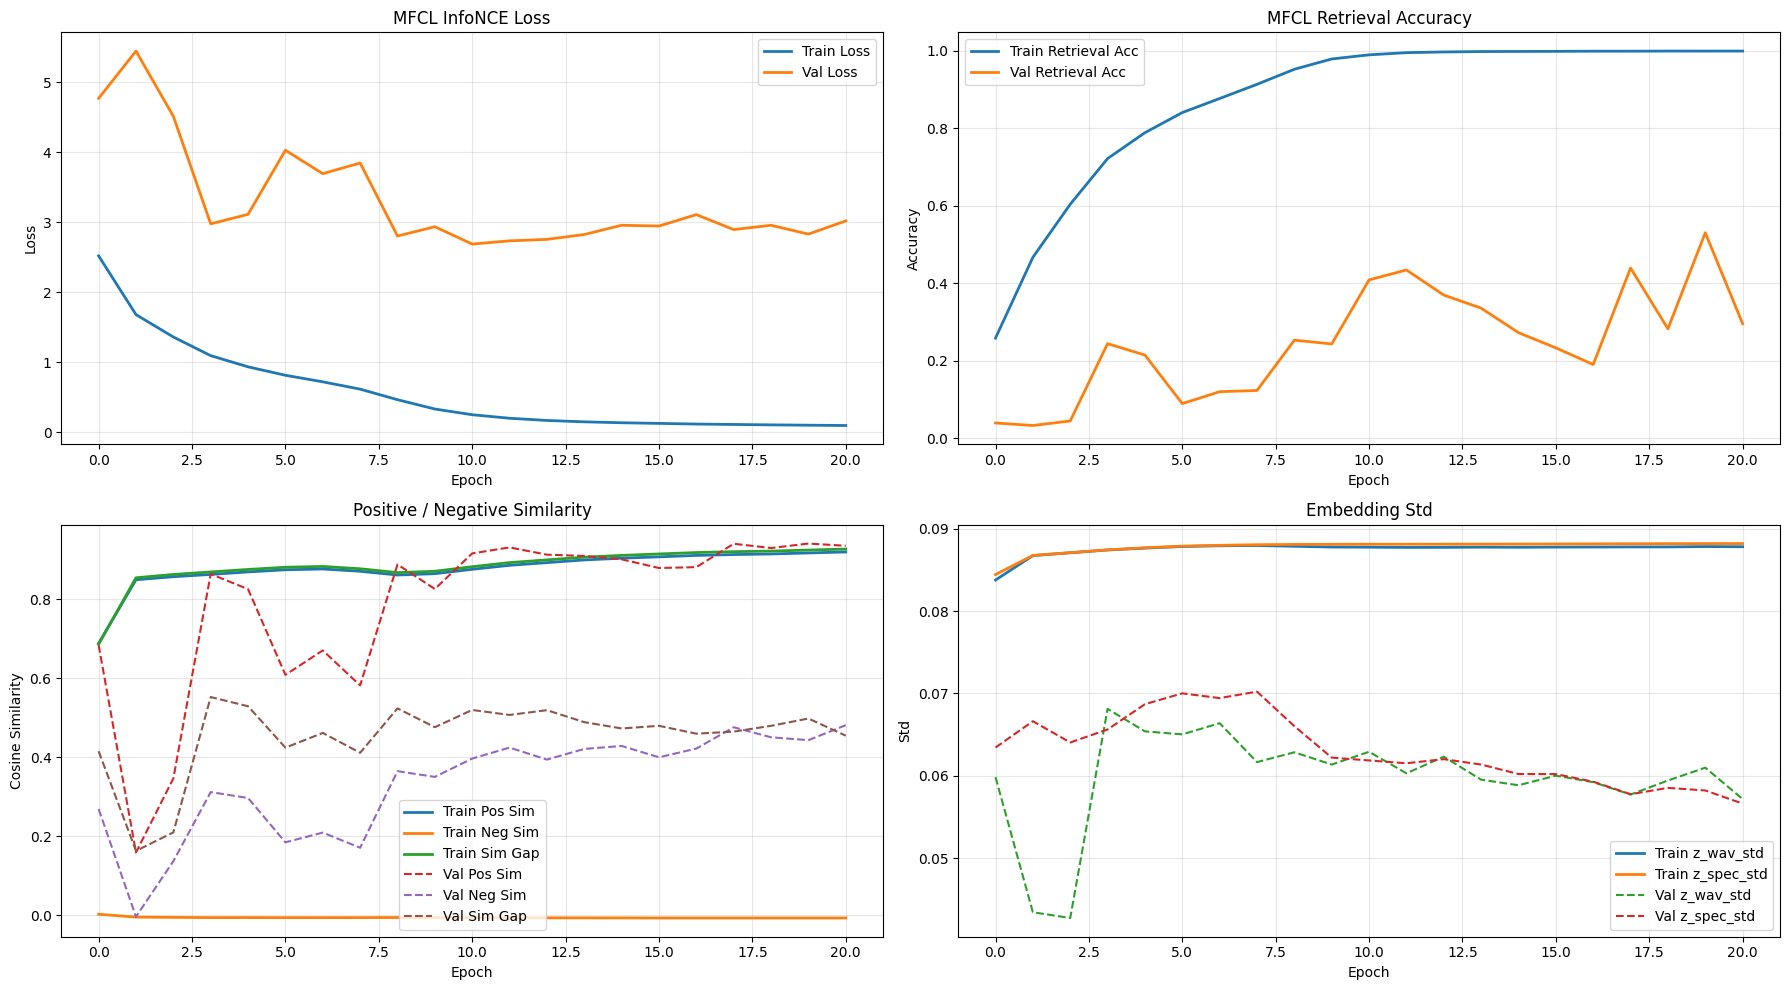

In [ ]:
metrics_path = os.path.join(logger.log_dir, "metrics.csv")
print("Metrics path:", metrics_path)
plot_mfcl_metrics(metrics_path)

1. Главная проблема — нет нормализации mel (снова)
```
mel = self.melspec(waveform)
```
и сразу в encoder

Это критично:
* амплитуда сильно гуляет
* contrastive loss становится нестабильным
* cosine similarity хуже работает

Fix (обязательно)
```
mel = self.melspec(waveform)
mel = (mel - mel.mean(dim=(-1, -2), keepdim=True)) / (mel.std(dim=(-1, -2), keepdim=True) + 1e-6)
```

2. Collapse эмбеддингов (очень вероятно)
Вы используете cosine similarity:
```
z = F.normalize(...)
logits = z_wav @ z_spec.T
```
НО:
* нет explicit regularization
* нет stop-gradient (как в BYOL / SimSiam)
* нет variance loss

Симптомы collapse (смотрите по логам):
`z_wav_std` и `z_spec_std` - если они стремятся к 0 → модель схлопнулась.

Минимальный фикс -  добавьте variance regularization:
```
def variance_loss(z, eps=1e-4):
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(F.relu(1 - std))
```
и вставьте в loss:
```
loss += 0.1 * (variance_loss(z_wav) + variance_loss(z_spec))
```
3.  Batch size критически важен. Если batch < 64,  модель будет учиться плохо.

4. Wave encoder слабее spec encoder. Сейчас imbalance:
* spec → 2D ResNet (сильный)
* wave → 1D ResNet (слабее для аудио)

эффект:
* модель "читит"
* учится через spectrogram путь
* wave encoder деградирует

Fix идеи:

1. Усилить wave encoder:
 * больше каналов
 * или pretrained
2. Или ослабить spec: 
 * меньше capacity

5. Нет аугментаций для contrastive learning. 
Сейчас `waveform` → один и тот же → два view

это не совсем contrastive

проблема:
* views слишком похожи
* модель учится identity mapping

Лучше два разных view:
```
wav1 = augment(waveform)
wav2 = augment(waveform)
```
```
z_wav = encode_wave(wav1)
z_spec = encode_spec(wav2)
```

6. Температура фиксированная (temperature = 0.1).
это ок, но иногда лучше учить её:
```
self.temperature = nn.Parameter(torch.tensor(0.1))
```

7. Симметричный loss `(loss_ws + loss_sw)`  — хорошо, но
* удваивает шум градиентов
* иногда достаточно одного направления

8. Нет `detach` (опасно для стабильности), сейчас оба обновляются одновременно z_wav ↔ z_spec. 

иногда это вызывает:
* нестабильность
* oscillation

Альтернатива (SimSiam-style):
```
loss_ws = CE(z_wav @ z_spec.detach().T)
loss_sw = CE(z_spec @ z_wav.detach().T)
```
9. Projection head может быть избыточным:
`Linear → BN → ReLU → Dropout → Linear → BN → ReLU → Dropout → Linear`
для AudioMNIST это может быть overkill

10. Нет gradient scaling для cosine similarity.
Иногда полезно:
```
logits = (z_wav @ z_spec.T) / temp
```
НО можно добавить learnable scale или clamp

---

Вот это уже серьёзная архитектура — фактически Вы реализовали что-то в духе cross-modal contrastive learning (wave ↔ mel). Это уровень выше обычного классификатора 👍

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


### Dataset

In [ ]:
class AudioMNISTPairDataset(torch.utils.data.Dataset):
    """
    Returns two stochastic waveform views of the same audio sample.
    Used for SimSiam / non-contrastive SSL.

    Output:
        view1: [1, T]
        view2: [1, T]
        label: int
    """
    def __init__(
        self,
        root,
        is_test: bool = False,
        augmentations=None,
        sr: int = 16000,
        max_duration_sec: float = 1.0,
    ):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)
        self.augmentations = augmentations
        self.is_test = is_test
        self.target_length = int(sr * max_duration_sec)

    def __len__(self):
        return len(self.items)

    def list_wavs_and_labels(self, root: str):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []
        for sp in speakers:
            for wav in sorted(sp.glob("**/*.wav")):
                name = wav.stem.split("_")
                digit = int(name[0])
                speaker_id = sp.name
                items.append((str(wav), digit, speaker_id))
        return items

    def load_wav(self, path: str) -> torch.Tensor:
        wav, sr = torchaudio.load(path)  # [C, T]

        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)

        wav = wav.mean(dim=0, keepdim=True)  # [1, T]

        current_length = wav.size(1)
        if current_length > self.target_length:
            wav = wav[:, :self.target_length]
        elif current_length < self.target_length:
            pad_amount = self.target_length - current_length
            wav = F.pad(wav, (0, pad_amount))

        return wav

    def _augment_once(self, wav: torch.Tensor) -> torch.Tensor:
        if self.augmentations is None:
            return wav.clone()

        # torch_audiomentations expects [B, C, T]
        aug_wav = self.augmentations(
            samples=wav.unsqueeze(0),   # [1, 1, T]
            sample_rate=self.sr,
        ).squeeze(0)                    # [1, T]

        aug_wav = torch.clamp(aug_wav, -1.0, 1.0)
        return aug_wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        if self.is_test:
            # deterministic validation: no stochastic augmentations
            view1 = wav.clone()
            view2 = wav.clone()
        else:
            view1 = self._augment_once(wav)
            view2 = self._augment_once(wav)

        return view1, view2, label


def collate_pairs(batch):
    view1, view2, labels = zip(*batch)

    view1 = torch.stack([x.squeeze(0) for x in view1], dim=0)  # [B, T]
    view2 = torch.stack([x.squeeze(0) for x in view2], dim=0)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)

    return view1, view2, labels

In [ ]:
from torch_audiomentations import Compose, Gain, AddColoredNoise, Shift

ssl_train_augmentations = Compose(
    transforms=[
        Gain(
            min_gain_in_db=-6.0,
            max_gain_in_db=6.0,
            p=0.25,
        ),
        AddColoredNoise(
            min_snr_in_db=12.0,
            max_snr_in_db=30.0,
            p=0.20,
        ),
        Shift(
            min_shift=-0.10,
            max_shift=0.10,
            p=0.20,
        ),
    ]
)

In [ ]:
class AudioPairDataModule(pl.LightningDataModule):
    def __init__(self, config: Config):
        super().__init__()
        self.root = config.data_path
        self.batch_size = config.batch_size
        self.num_workers = config.num_workers
        self.num_test_speakers = config.num_test_speakers
        self.sample_rate = config.sample_rate
        self.max_duration_sec = config.max_duration_sec

    def split_indices_by_speaker(self, dataset, test_speakers):
        train_idxs = []
        valid_idxs = []

        for idx, (_, _, spk) in enumerate(dataset.items):
            if spk in test_speakers:
                valid_idxs.append(idx)
            else:
                train_idxs.append(idx)

        return train_idxs, valid_idxs

    def setup(self, stage=None):
        full_ds = AudioMNISTPairDataset(
            root=self.root,
            is_test=False,
            augmentations=None,
            sr=self.sample_rate,
            max_duration_sec=self.max_duration_sec,
        )

        all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
        valid_speakers = set(all_speakers[-self.num_test_speakers:])

        train_idxs, valid_idxs = self.split_indices_by_speaker(full_ds, valid_speakers)

        train_full = AudioMNISTPairDataset(
            root=self.root,
            is_test=False,
            augmentations=ssl_train_augmentations,
            sr=self.sample_rate,
            max_duration_sec=self.max_duration_sec,
        )

        valid_full = AudioMNISTPairDataset(
            root=self.root,
            is_test=True,
            augmentations=None,
            sr=self.sample_rate,
            max_duration_sec=self.max_duration_sec,
        )

        self.train_ds = Subset(train_full, train_idxs)
        self.valid_ds = Subset(valid_full, valid_idxs)

        print("Train samples:", len(train_idxs))
        print("Valid samples:", len(valid_idxs))
        print("Valid speakers:", sorted(valid_speakers))

        train_speakers = {spk for i in train_idxs for (_, _, spk) in [full_ds.items[i]]}
        valid_speakers_check = {spk for i in valid_idxs for (_, _, spk) in [full_ds.items[i]]}
        print("Speakers leakage:", bool(train_speakers & valid_speakers_check))

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
            pin_memory=True,
            collate_fn=collate_pairs,
            drop_last=True,   # важно для BatchNorm и стабильности SSL
        )

    def val_dataloader(self):
        return DataLoader(
            self.valid_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=self.num_workers > 0,
            pin_memory=True,
            collate_fn=collate_pairs,
            drop_last=False,
        )

### Model

In [ ]:
class PredictorHead(nn.Module):
    """
    SimSiam predictor: maps projected embedding to prediction space.
    """
    def __init__(self, in_dim: int, hidden_dim: int = 256, out_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [ ]:
def negative_cosine_similarity(p: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    """
    SimSiam loss term:
        D(p, z) = - cos_sim(normalize(p), normalize(z))
    z must be stop-gradient target.
    """
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return -F.cosine_similarity(p, z, dim=1).mean()


def retrieval_accuracy(z_a: torch.Tensor, z_b: torch.Tensor) -> torch.Tensor:
    """
    Cross-format retrieval accuracy for monitoring.
    Keeps comparison with InfoNCE setup interpretable.
    """
    z_a = F.normalize(z_a, dim=1)
    z_b = F.normalize(z_b, dim=1)

    sim = z_a @ z_b.T
    targets = torch.arange(sim.size(0), device=sim.device)

    acc_ab = (sim.argmax(dim=1) == targets).float().mean()
    acc_ba = (sim.T.argmax(dim=1) == targets).float().mean()
    return 0.5 * (acc_ab + acc_ba)

In [ ]:
class SimSiamMFCLLitModule(pl.LightningModule):
    def __init__(
        self,
        sample_rate: int = 16000,
        n_fft: int = 1024,
        hop_length: int = 256,
        win_length: int = 1024,
        n_mels: int = 64,
        emb_dim: int = 128,
        proj_dim: int = 128,
        pred_hidden_dim: int = 256,
        lr: float = 3e-4,
        weight_decay: float = 1e-3,
        dropout_p: float = 0.2,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.melspec = LogMelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
            eps=1e-6,
        )

        self.wav_encoder = WaveEncoder1D(
            emb_dim=emb_dim,
            dropout_p=dropout_p,
        )
        self.spec_encoder = SpecEncoder2D(
            img_channels=1,
            emb_dim=emb_dim,
            dropout_p=dropout_p,
        )

        self.wav_proj = ProjectionHead(
            in_dim=emb_dim,
            proj_dim=proj_dim,
            dropout_p=dropout_p,
        )
        self.spec_proj = ProjectionHead(
            in_dim=emb_dim,
            proj_dim=proj_dim,
            dropout_p=dropout_p,
        )

        self.wav_pred = PredictorHead(
            in_dim=proj_dim,
            hidden_dim=pred_hidden_dim,
            out_dim=proj_dim,
        )
        self.spec_pred = PredictorHead(
            in_dim=proj_dim,
            hidden_dim=pred_hidden_dim,
            out_dim=proj_dim,
        )

    def encode_wave(self, waveform: torch.Tensor):
        """
        waveform: [B, T] or [B, 1, T]
        returns:
            z_wav: [B, proj_dim]
            p_wav: [B, proj_dim]
        """
        if waveform.dim() == 2:
            waveform = waveform.unsqueeze(1)  # [B, 1, T]
        elif waveform.dim() != 3:
            raise ValueError(f"Unexpected waveform shape: {waveform.shape}")

        wav_emb = self.wav_encoder(waveform)   # [B, emb_dim]
        z_wav = self.wav_proj(wav_emb)         # [B, proj_dim]
        p_wav = self.wav_pred(z_wav)           # [B, proj_dim]
        return z_wav, p_wav

    def encode_spec(self, waveform: torch.Tensor):
        """
        waveform: [B, T] or [B, 1, T]
        returns:
            z_spec: [B, proj_dim]
            p_spec: [B, proj_dim]
        """
        if waveform.dim() == 3:
            waveform = waveform.squeeze(1)  # [B, T]
        elif waveform.dim() != 2:
            raise ValueError(f"Unexpected waveform shape: {waveform.shape}")

        mel = self.melspec(waveform)      # [B, n_mels, time]
        mel = mel.unsqueeze(1)            # [B, 1, n_mels, time]

        spec_emb, _ = self.spec_encoder(mel)
        z_spec = self.spec_proj(spec_emb)
        p_spec = self.spec_pred(z_spec)
        return z_spec, p_spec

    def forward(self, view1: torch.Tensor, view2: torch.Tensor):
        z_wav_1, p_wav_1 = self.encode_wave(view1)
        z_wav_2, p_wav_2 = self.encode_wave(view2)

        z_spec_1, p_spec_1 = self.encode_spec(view1)
        z_spec_2, p_spec_2 = self.encode_spec(view2)

        return {
            "z_wav_1": z_wav_1,
            "p_wav_1": p_wav_1,
            "z_wav_2": z_wav_2,
            "p_wav_2": p_wav_2,
            "z_spec_1": z_spec_1,
            "p_spec_1": p_spec_1,
            "z_spec_2": z_spec_2,
            "p_spec_2": p_spec_2,
        }

    def simsiam_pair_loss(
        self,
        p1: torch.Tensor,
        z2: torch.Tensor,
        p2: torch.Tensor,
        z1: torch.Tensor,
    ) -> torch.Tensor:
        loss_12 = negative_cosine_similarity(p1, z2.detach())
        loss_21 = negative_cosine_similarity(p2, z1.detach())
        return 0.5 * (loss_12 + loss_21)

    def _shared_step(self, batch, stage: str):
        view1, view2, _ = batch

        out = self(view1, view2)

        wave_loss = self.simsiam_pair_loss(
            out["p_wav_1"], out["z_wav_2"],
            out["p_wav_2"], out["z_wav_1"],
        )

        spec_loss = self.simsiam_pair_loss(
            out["p_spec_1"], out["z_spec_2"],
            out["p_spec_2"], out["z_spec_1"],
        )

        loss = 0.5 * (wave_loss + spec_loss)

        # diagnostic cross-format retrieval on same view only
        cross_acc_v1 = retrieval_accuracy(out["z_wav_1"], out["z_spec_1"])
        cross_acc_v2 = retrieval_accuracy(out["z_wav_2"], out["z_spec_2"])
        cross_acc = 0.5 * (cross_acc_v1 + cross_acc_v2)

        z_wav_std = 0.5 * (
            out["z_wav_1"].std(dim=0).mean() +
            out["z_wav_2"].std(dim=0).mean()
        )
        z_spec_std = 0.5 * (
            out["z_spec_1"].std(dim=0).mean() +
            out["z_spec_2"].std(dim=0).mean()
        )
        z_std = 0.5 * (z_wav_std + z_spec_std)

        batch_size = view1.size(0)

        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}_wave_loss", wave_loss, prog_bar=False, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}_spec_loss", spec_loss, prog_bar=False, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}_acc", cross_acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=batch_size)

        self.log(f"{stage}_z_std", z_std, prog_bar=False, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}_z_wav_std", z_wav_std, prog_bar=False, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f"{stage}_z_spec_std", z_spec_std, prog_bar=False, on_step=False, on_epoch=True, batch_size=batch_size)

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )

        # для SSL обычно работает стабильнее, чем ReduceLROnPlateau
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.trainer.max_epochs,
            eta_min=1e-6,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            },
        }

### Training and Evaluation

In [ ]:
dm_ssl = AudioPairDataModule(config)

model_mfcl_simsiam = SimSiamMFCLLitModule(
    sample_rate=16000,
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_mels=64,
    emb_dim=128,
    proj_dim=128,
    pred_hidden_dim=256,
    lr=3e-4,
    weight_decay=1e-3,
    dropout_p=0.2,
)

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="mfcl-simsiam-{epoch:02d}-{val_loss:.4f}",
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    mode="min",
)

logger = CSVLogger("logs", name="mfcl_simsiam_audio")

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
precision = "16-mixed" if torch.cuda.is_available() else 32

trainer = pl.Trainer(
    max_epochs=100,
    accelerator=accelerator,
    devices=1,
    precision=precision,
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

trainer.fit(model_mfcl_simsiam, dm_ssl)

print("Best checkpoint:", checkpoint_callback.best_model_path)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Train samples: 24000
Valid samples: 6000
Valid speakers: ['49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60']
Speakers leakage: False


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ melspec      │ LogMelSpectrogram │      0 │ train │     0 │
│ 1 │ wav_encoder  │ WaveEncoder1D     │  3.0 M │ train │     0 │
│ 2 │ spec_encoder │ SpecEncoder2D     │  7.1 M │ train │     0 │
│ 3 │ wav_proj     │ ProjectionHead    │  132 K │ train │     0 │
│ 4 │ spec_proj    │ ProjectionHead    │  132 K │ train │     0 │
│ 5 │ wav_pred     │ PredictorHead     │ 66.2 K │ train │     0 │
│ 6 │ spec_pred    │ PredictorHead     │ 66.2 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 10.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.6 M                                                                                               
Total estimated model params size (MB): 42                                                                         
Modules in train mode: 189                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Best checkpoint: logs/mfcl_simsiam_audio/version_4/checkpoints/mfcl-simsiam-epoch=24-val_loss=-0.9994.ckpt


### Metrics and Visualisation

Metrics path: logs/mfcl_simsiam_audio/version_4/metrics.csv


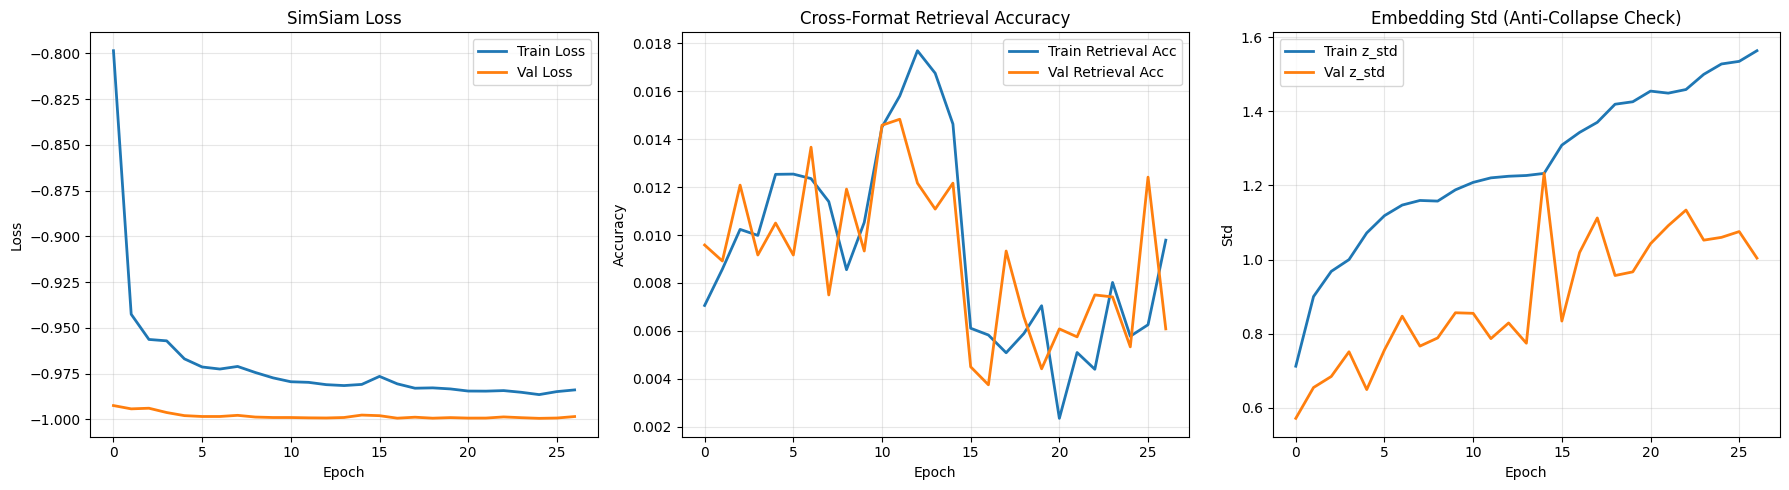

In [ ]:
def plot_simsiam_metrics(metrics_path: str):
    metrics_df = pd.read_csv(metrics_path)

    train_metrics = metrics_df.dropna(subset=["train_loss"]).copy()
    val_metrics = metrics_df.dropna(subset=["val_loss"]).copy()

    train_metrics = train_metrics.groupby("epoch", as_index=False).last()
    val_metrics = val_metrics.groupby("epoch", as_index=False).last()

    common_epochs = sorted(set(train_metrics["epoch"]) & set(val_metrics["epoch"]))
    train_metrics = train_metrics[train_metrics["epoch"].isin(common_epochs)].sort_values("epoch")
    val_metrics = val_metrics[val_metrics["epoch"].isin(common_epochs)].sort_values("epoch")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(train_metrics["epoch"], train_metrics["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(val_metrics["epoch"], val_metrics["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_title("SimSiam Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Retrieval accuracy
    axes[1].plot(train_metrics["epoch"], train_metrics["train_acc"], label="Train Retrieval Acc", linewidth=2)
    axes[1].plot(val_metrics["epoch"], val_metrics["val_acc"], label="Val Retrieval Acc", linewidth=2)
    axes[1].set_title("Cross-Format Retrieval Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Embedding std
    if "train_z_std" in train_metrics.columns and "val_z_std" in val_metrics.columns:
        axes[2].plot(train_metrics["epoch"], train_metrics["train_z_std"], label="Train z_std", linewidth=2)
        axes[2].plot(val_metrics["epoch"], val_metrics["val_z_std"], label="Val z_std", linewidth=2)
        axes[2].set_title("Embedding Std (Anti-Collapse Check)")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Std")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()
    else:
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()


metrics_path = os.path.join(logger.log_dir, "metrics.csv")
print("Metrics path:", metrics_path)
plot_simsiam_metrics(metrics_path)

1.  Главная проблема — views слишком слабые
```
view1 = self._augment_once(wav)
view2 = self._augment_once(wav)
```
А аугментации:
* Gain p=0.25
* Noise p=0.20
* Shift p=0.20

Вероятность, что ничего не применится `~ 0.75 * 0.8 * 0.8 ≈ 0.48`

Почти половина батча = одинаковые view

Почему это критично для SimSiam:
* SimSiam НЕ имеет negative samples
* SimSiam НЕ имеет contrastive pressure

SimSiam живёт за счёт "разные view одного объекта".

Если view одинаковые → модель учит identity → collapse.

Fix. Сделайте агрессивнее:
```
Compose([
    OneOf([
        Gain(...),
        AddColoredNoise(...),
        Shift(...),
    ], p=0.9),
])
```
или просто `p = 0.5–0.8` для каждого.

2. Нет нормализации mel (снова…)
```
mel = self.melspec(waveform)
```
В SimSiam это ещё хуже:
* cosine similarity чувствителен к scale
* нестабильные градиенты

Fix (обязательно)
```
mel = self.melspec(waveform)
mel = (mel - mel.mean(dim=(-1, -2), keepdim=True)) / (mel.std(dim=(-1, -2), keepdim=True) + 1e-6)
```

3. Нет cross-modal связи (самая интересная проблема).
Сейчас loss
```
loss = 0.5 * (wave_loss + spec_loss)
```
это:
* SimSiam для wave
* SimSiam для spec
НО они вообще не взаимодействуют! 

Что происходит:
* wave encoder учится сам по себе
* spec encoder учится сам по себе
Вы НЕ используете идею MFCL (cross-modal learning)

Fix (ключевой) добавить cross loss:
```
cross_loss = self.simsiam_pair_loss(
    out["p_wav_1"], out["z_spec_2"],
    out["p_spec_2"], out["z_wav_1"],
)
```
```
loss = 0.33 * (wave_loss + spec_loss + cross_loss)
```
4. Возможен collapse (и Вы почти его ловите)

Fix (очень рекомендую)
```
def variance_loss(z, eps=1e-4):
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(F.relu(1 - std))
```
```
loss += 0.05 * (
    variance_loss(out["z_wav_1"]) +
    variance_loss(out["z_spec_1"])
)
```
5. Crop до аугментаций (об этом уже писал в п.1)

6. Predictor может быть слабоват. для SimSiam иногда делают:
* больше hidden dim
* deeper MLP

7. Batch size всё ещё критичен.

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

### Setup and Helpers

In [ ]:
def to_waveform_bt(waveform: torch.Tensor) -> torch.Tensor:
    """
    Convert waveform to [B, T]
    """
    if waveform.dim() == 2:
        return waveform
    if waveform.dim() == 3 and waveform.size(1) == 1:
        return waveform.squeeze(1)
    raise ValueError(f"Unexpected waveform shape: {waveform.shape}")


def to_waveform_bct(waveform: torch.Tensor) -> torch.Tensor:
    """
    Convert waveform to [B, 1, T]
    """
    if waveform.dim() == 2:
        return waveform.unsqueeze(1)
    if waveform.dim() == 3 and waveform.size(1) == 1:
        return waveform
    raise ValueError(f"Unexpected waveform shape: {waveform.shape}")

### Feature extraction

In [ ]:
@torch.no_grad()
def extract_supervised_features(model, dataloader, device):
    """
    Extract frozen features from the supervised model.
    Uses the 2D spectrogram backbone features before classification head.
    Returns:
        X: [N, D]
        y: [N]
    """
    model.eval().to(device)

    all_features = []
    all_labels = []

    for waveform, labels in tqdm(dataloader, desc="Extract supervised features"):
        waveform = waveform.to(device)
        labels = labels.to(device)

        waveform_bt = to_waveform_bt(waveform)
        mel = model.melspec(waveform_bt)      # [B, n_mels, time]
        mel = mel.unsqueeze(1)                # [B, 1, n_mels, time]

        _, features = model.encoder(mel)      # [B, 512]

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())

    X = torch.cat(all_features, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()
    return X, y


@torch.no_grad()
def extract_mfcl_features(model, dataloader, device, combine="concat"):
    """
    Extract frozen features from InfoNCE model.
    combine:
        - 'wav'    : use waveform branch only
        - 'spec'   : use spectrogram branch only
        - 'concat' : concatenate both
    Returns:
        X: [N, D]
        y: [N]
    """
    model.eval().to(device)

    all_features = []
    all_labels = []

    for waveform, labels in tqdm(dataloader, desc=f"Extract MFCL features ({combine})"):
        waveform = waveform.to(device)
        labels = labels.to(device)

        waveform_bt = to_waveform_bt(waveform)
        waveform_bct = to_waveform_bct(waveform)

        wav_emb = model.wav_encoder(waveform_bct)   # [B, emb_dim]

        mel = model.melspec(waveform_bt)            # [B, n_mels, time]
        mel = mel.unsqueeze(1)                      # [B, 1, n_mels, time]
        spec_emb, _ = model.spec_encoder(mel)       # [B, emb_dim]

        if combine == "wav":
            features = wav_emb
        elif combine == "spec":
            features = spec_emb
        elif combine == "concat":
            features = torch.cat([wav_emb, spec_emb], dim=1)
        else:
            raise ValueError(f"Unknown combine mode: {combine}")

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())

    X = torch.cat(all_features, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()
    return X, y


@torch.no_grad()
def extract_simsiam_features(model, dataloader, device, combine="concat"):
    """
    Extract frozen features from SimSiam model.
    We use projected embeddings z_wav / z_spec, not predictors p_*.
    combine:
        - 'wav'
        - 'spec'
        - 'concat'
    """
    model.eval().to(device)

    all_features = []
    all_labels = []

    for waveform, labels in tqdm(dataloader, desc=f"Extract SimSiam features ({combine})"):
        waveform = waveform.to(device)
        labels = labels.to(device)

        waveform_bt = to_waveform_bt(waveform)
        waveform_bct = to_waveform_bct(waveform)

        wav_emb = model.wav_encoder(waveform_bct)
        z_wav = model.wav_proj(wav_emb)

        mel = model.melspec(waveform_bt)
        mel = mel.unsqueeze(1)
        spec_emb, _ = model.spec_encoder(mel)
        z_spec = model.spec_proj(spec_emb)

        if combine == "wav":
            features = z_wav
        elif combine == "spec":
            features = z_spec
        elif combine == "concat":
            features = torch.cat([z_wav, z_spec], dim=1)
        else:
            raise ValueError(f"Unknown combine mode: {combine}")

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())

    X = torch.cat(all_features, dim=0).numpy()
    y = torch.cat(all_labels, dim=0).numpy()
    return X, y


### Linear probe evaluation

In [ ]:
def fit_linear_probe(X_train, y_train, X_val, y_val, name="model"):
    """
    Train linear classifier on frozen embeddings and evaluate on validation.
    """
    clf = LogisticRegression(
        max_iter=3000,
        multi_class="multinomial",
        solver="lbfgs",
        n_jobs=None,
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, digits=4))

    return {
        "setup": name,
        "val_accuracy": acc,
        "val_macro_f1": macro_f1,
    }

In [ ]:
@torch.no_grad()
def evaluate_supervised_classifier(model, dataloader, device):
    model.eval().to(device)

    y_true = []
    y_pred = []

    for waveform, labels in tqdm(dataloader, desc="Evaluate supervised classifier"):
        waveform = waveform.to(device)
        labels = labels.to(device)

        logits = model(to_waveform_bt(waveform))
        preds = logits.argmax(dim=1)

        y_true.append(labels.cpu())
        y_pred.append(preds.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print("\n=== Supervised end-to-end classifier ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "setup": "supervised_end_to_end",
        "val_accuracy": acc,
        "val_macro_f1": macro_f1,
    }

### Comparison

In [ ]:
def find_latest_ckpt_by_model_name(root_dir: str, model_name: str) -> Optional[str]:
    root = Path(root_dir)
    if not root.exists():
        return None

    normalized_query = model_name.lower().replace("_", "-")

    candidates = []
    for p in root.rglob("*.ckpt"):
        normalized_name = p.name.lower().replace("_", "-")
        if normalized_query in normalized_name:
            candidates.append(p)

    if not candidates:
        return None

    latest_ckpt = max(candidates, key=lambda p: p.stat().st_mtime)
    return str(latest_ckpt)

In [ ]:
best_sup_ckpt = find_latest_ckpt_by_model_name(
    root_dir="/kaggle/working/logs",
    model_name="supervised-audio",
)

model_supervised = AudioClassifierLitModule.load_from_checkpoint(best_sup_ckpt)
model_supervised.eval()
model_supervised.to(config.device)

print(f"Loaded supervised-audio from {best_sup_ckpt}")

best_mfcl_ckpt = find_latest_ckpt_by_model_name(
    root_dir="/kaggle/working/logs",
    model_name="mfcl_audio",
)

print (best_mfcl_ckpt)
model_mfcl = MFCLLitModule.load_from_checkpoint(best_mfcl_ckpt)
model_mfcl.eval().to(config.device)

print(f"Loaded mfcl_audio from {best_mfcl_ckpt}")

best_simsiam_ckpt = find_latest_ckpt_by_model_name(
    root_dir="/kaggle/working/logs",
    model_name="mfcl-simsiam",
)

print (best_simsiam_ckpt)
model_mfcl_simsiam = SimSiamMFCLLitModule.load_from_checkpoint(best_simsiam_ckpt)
model_mfcl_simsiam.eval().to(config.device)

print(f"Loaded mfcl_simsiam_audio from {best_simsiam_ckpt}")

Loaded supervised-audio from /kaggle/working/logs/supervised_audio/version_7/checkpoints/supervised-audio-epoch=14-val_acc=1.00.ckpt
/kaggle/working/logs/mfcl_audio/version_1/checkpoints/mfcl-audio-epoch=05-val_loss=2.4483.ckpt
Loaded mfcl_audio from /kaggle/working/logs/mfcl_audio/version_1/checkpoints/mfcl-audio-epoch=05-val_loss=2.4483.ckpt
/kaggle/working/logs/mfcl_simsiam_audio/version_4/checkpoints/mfcl-simsiam-epoch=24-val_loss=-0.9994.ckpt
Loaded mfcl_simsiam_audio from /kaggle/working/logs/mfcl_simsiam_audio/version_4/checkpoints/mfcl-simsiam-epoch=24-val_loss=-0.9994.ckpt


In [ ]:
# Reuse the same split
dm_eval = AudioDataModule(config)
dm_eval.setup()

train_loader = dm_eval.train_dataloader()
val_loader = dm_eval.val_dataloader()

results = []

# 1) Supervised model: end-to-end classifier result
results.append(evaluate_supervised_classifier(model=copy.deepcopy(model_supervised),
                                              dataloader=val_loader,
                                              device=config.device))

# 2) Supervised model: frozen feature extractor + linear probe
X_train_sup, y_train_sup = extract_supervised_features(copy.deepcopy(model_supervised), train_loader, config.device)
X_val_sup, y_val_sup = extract_supervised_features(copy.deepcopy(model_supervised), val_loader, config.device)
results.append(fit_linear_probe(X_train_sup, y_train_sup, X_val_sup, y_val_sup, name="supervised_linear_probe"))

# 3) InfoNCE / MFCL
X_train_mfcl, y_train_mfcl = extract_mfcl_features(copy.deepcopy(model_mfcl), train_loader, config.device, combine="concat")
X_val_mfcl, y_val_mfcl = extract_mfcl_features(copy.deepcopy(model_mfcl), val_loader, config.device, combine="concat")
results.append(fit_linear_probe(X_train_mfcl, y_train_mfcl, X_val_mfcl, y_val_mfcl, name="mfcl_infonce_linear_probe"))

# 4) SimSiam / NCL
X_train_sim, y_train_sim = extract_simsiam_features(copy.deepcopy(model_mfcl_simsiam), train_loader, config.device, combine="concat")
X_val_sim, y_val_sim = extract_simsiam_features(copy.deepcopy(model_mfcl_simsiam), val_loader, config.device, combine="concat")
results.append(fit_linear_probe(X_train_sim, y_train_sim, X_val_sim, y_val_sim, name="simsiam_linear_probe"))

results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
print("\n=== Final comparison ===")
display(results_df)

Train samples: 24000
Valid samples: 6000
Valid speakers: ['49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60']
Speakers leakage: False


Evaluate supervised classifier:   0%|          | 0/47 [00:00<?, ?it/s]


=== Supervised end-to-end classifier ===
Accuracy: 0.9965
Macro F1: 0.9965
              precision    recall  f1-score   support

           0     1.0000    0.9917    0.9958       600
           1     0.9901    1.0000    0.9950       600
           2     0.9901    1.0000    0.9950       600
           3     0.9917    0.9983    0.9950       600
           4     0.9983    0.9883    0.9933       600
           5     0.9967    0.9967    0.9967       600
           6     1.0000    1.0000    1.0000       600
           7     1.0000    1.0000    1.0000       600
           8     1.0000    0.9983    0.9992       600
           9     0.9983    0.9917    0.9950       600

    accuracy                         0.9965      6000
   macro avg     0.9965    0.9965    0.9965      6000
weighted avg     0.9965    0.9965    0.9965      6000



Extract supervised features:   0%|          | 0/188 [00:00<?, ?it/s]

Extract supervised features:   0%|          | 0/47 [00:00<?, ?it/s]

...

Extract SimSiam features (concat):   0%|          | 0/188 [00:00<?, ?it/s]

Extract SimSiam features (concat):   0%|          | 0/47 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== simsiam_linear_probe ===
Accuracy: 0.5460
Macro F1: 0.5461
              precision    recall  f1-score   support

           0     0.7198    0.4667    0.5662       600
           1     0.4506    0.6000    0.5147       600
           2     0.3588    0.7033    0.4752       600
           3     0.3929    0.3300    0.3587       600
           4     0.7119    0.6467    0.6777       600
           5     0.6361    0.4283    0.5120       600
           6     0.6419    0.8217    0.7208       600
           7     0.6323    0.5217    0.5717       600
           8     0.8062    0.3883    0.5242       600
           9     0.5261    0.5533    0.5394       600

    accuracy                         0.5460      6000
   macro avg     0.5877    0.5460    0.5461      6000
weighted avg     0.5877    0.5460    0.5461      6000


=== Final comparison ===


,setup,val_accuracy,val_macro_f1
0,supervised_end_to_end,0.996500,0.996500
1,supervised_linear_probe,0.996167,0.996171
2,mfcl_infonce_linear_probe,0.732167,0.733601
3,simsiam_linear_probe,0.546000,0.546052


1. НЕТ нормализации mel при извлечении фич (самая большая проблема)

В итоге:
* train ≠ eval
* linear probe получает другие фичи

Fix (обязательно) - Добавьте ВЕЗДЕ:
```
mel = model.melspec(waveform_bt)
mel = (mel - mel.mean(dim=(-1, -2), keepdim=True)) / (mel.std(dim=(-1, -2), keepdim=True) + 1e-6)
```

То же самое в:
* extract_supervised_features
* extract_mfcl_features
* extract_simsiam_features

2. Вы используешьте НЕ те фичи для MFCL (это до projection head):
```
wav_emb = model.wav_encoder(waveform_bct)
spec_emb, _ = model.spec_encoder(mel)
```
Проблема - Модель обучалась на:
```
z = projection(embedding), 
```
а Вы берёте embedding (до projection)

Что лучше использовать - Для contrastive моделей обычно использовать после projection:
```
z_wav = model.wav_proj(wav_emb)
z_spec = model.spec_proj(spec_emb)
```
3.  В SimSiam тоже нет нормализации перед probe:
```
features = z_wav / z_spec
```
Проблема - SimSiam работает в cosine space, но linear probe чувствителен к scale.

Fix:
```
features = F.normalize(features, dim=1)
```
4. Возможный data leakage (тонкий момент) - Вы используете dataloader. Вопрос: это точно val_loader, а не train? Если перепутать, получите нереалистично высокий accuracy.

5. LogisticRegression может быть нестабильным.
```
LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
)
```
проблемы:
* плохо работает с неотмасштабированными фичами
* чувствителен к scale

Лучше:
```
Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(...))
])
```
6. concat
```
features = torch.cat([wav_emb, spec_emb], dim=1)
```
может портить баланс, если одна модальность сильнее → доминирует

лучше:
```
features = torch.cat([
    F.normalize(wav_emb, dim=1),
    F.normalize(spec_emb, dim=1)
], dim=1)
```
7. `find_latest_ckpt` — может выбрать не лучший чекпоинт. лучше использовать `best_model_path` из `callback` или парсить `val_loss` из имени

В рамках Task 4 были сравнены три подхода к обучению аудио-представлений:

1. **Supervised learning**
2. **Multi-Format Contrastive Learning (InfoNCE)**
3. **non-contrastive learning (SimSiam-style)**

Лучший результат показала **supervised-модель**.
Полностью обученный классификатор достиг **0.9965 accuracy / 0.9965 macro-F1**, а linear probe на замороженных supervised-признаках показал почти такой же результат — **0.9962 accuracy / 0.9962 macro-F1**. Это означает, что supervised encoder выучил очень качественные, хорошо разделимые и информативные представления.

Модель **MFCL с InfoNCE** показала **0.7322 accuracy / 0.7336 macro-F1** в режиме linear probe. Это говорит о том, что self-supervised представления действительно содержат полезную информацию о классе, однако по качеству они заметно уступают supervised-признакам для задачи классификации цифр.

Худший результат показала **SimSiam-based non-contrastive модель**: **0.5460 accuracy / 0.5461 macro-F1**. Вероятная причина заключается в том, что в текущей реализации objective хорошо согласует два аугментированных представления внутри одной ветки (waveform-to-waveform и spectrogram-to-spectrogram), но не обеспечивает достаточно сильного выравнивания между waveform и spectrogram представлениями одного и того же аудиосигнала. Из-за этого learned embeddings оказываются менее полезными для downstream-классификации.

Таким образом, результаты эксперимента показывают, что:

* **supervised learning** даёт наилучшие представления для данной задачи;
* **MFCL с InfoNCE** способен выучивать полезные self-supervised признаки, но их качество пока значительно ниже supervised baseline;
* **текущая non-contrastive SimSiam-постановка** менее эффективна для обучения cross-format аудио-представлений.

Если сравнивать именно качество представлений через **linear probe**, то итоговый порядок методов следующий:

**supervised features > MFCL (InfoNCE) > SimSiam-based NCL**

В целом можно сделать вывод, что для задачи классификации AudioMNIST в данной работе наиболее эффективным оказался **supervised подход**, тогда как self-supervised методы требуют дополнительной доработки архитектуры, функции потерь и стратегии согласования wave/spec представлений.
